In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import matplotlib
from scipy.integrate import quad

plt.style.use('sty.mplstyle')

def j1_aux(x):
    cond = x!=0
    main = 1/3*np.ones_like(x)
    num = np.sin(x[cond]) - x[cond]*np.cos(x[cond])
    denom = x[cond]**3
    main[cond] = num/denom
    return main

# Woods-Saxon Form Factor

In [2]:
AWS = 184
sigmaWS = 0.523/0.1973 # GeV^{-1}
rWS = 1.126*AWS**(1/3)/0.1973 # GeV^{-1}

def WS_FF(Q2):
    Q = np.sqrt(Q2)
    main = np.ones_like(Q2)
    cond = Q != 0
    num = np.pi*sigmaWS*np.cosh(np.pi*Q[cond]*sigmaWS)*np.sin(Q[cond]*rWS)/np.sinh(np.pi*Q[cond]*sigmaWS) - rWS*np.cos(Q[cond]*rWS)
    num *= 3*np.pi*sigmaWS
    denom = Q[cond]*rWS*np.sinh(np.pi*Q[cond]*sigmaWS)
    denom *= (rWS**2 + np.pi**2*sigmaWS**2)
    main[cond] = num/denom
    return main

# Helm Form Factor [v1]

In [3]:
cv1_Helm = 1.23*AWS**(1/3) - 0.6 # fm
r0v1_Helm = 0.52 # fm
sv1_Helm = 0.9 # fm
R0v1_Helm = cv1_Helm**2 + 7*np.pi**2*r0v1_Helm**2/3 - 5*sv1_Helm**2 # fm^2
R0v1_Helm = np.sqrt(R0v1_Helm) # fm
R0v1_Helm = R0v1_Helm/0.1973 # GeV^{-1}
sv1_Helm = sv1_Helm/0.1973 # GeV^{-1}

def Helm_FFv1(Q2):
    Q = np.sqrt(Q2)
    main = 3*j1_aux(Q*R0v1_Helm)*np.exp(-Q2*sv1_Helm**2/2)
    return main

# Helm Form Factor [v2]

In [4]:
cv2_Helm = 6.51 # fm
r0v2_Helm = 0.535 # fm
sv2_Helm = 0.9 # fm
R0v2_Helm = cv2_Helm**2 + 7*np.pi**2*r0v2_Helm**2/3 - 5*sv2_Helm**2 # fm^2
R0v2_Helm = np.sqrt(R0v2_Helm) # fm
R0v2_Helm = R0v2_Helm/0.1973 # GeV^{-1}
sv2_Helm = sv2_Helm/0.1973 # GeV^{-1}

def Helm_FFv2(Q2):
    Q = np.sqrt(Q2)
    main = 3*j1_aux(Q*R0v2_Helm)*np.exp(-Q2*sv2_Helm**2/2)
    return main

# Klein-Nystrand Form Factors

In [5]:
RA_KN = 1.23*AWS**(1/3) # fm
RA_KN = RA_KN/0.1973 # GeV^{-1}
r0_adKN = 5.3658 # fm
ak_adKN = 0.7 # fm
RA_adKN = np.sqrt( 5*r0_adKN**2/3 - 10*ak_adKN**2 ) # fm
RA_adKN = RA_adKN/0.1973 # GeV^{-1}

def KN_FF(Q2, R=1):
    ak_aux = 0.7/0.1973 # GeV^{-1}
    Q = np.sqrt(Q2)
    num = 3*j1_aux(Q*R)
    denom = 1 + Q2*ak_aux**2
    return num/denom

In [6]:
Qmax = 0.7 # GeV
Qvals = np.linspace(0, Qmax, 500)

abs_WS_FF = np.abs( WS_FF(Qvals**2) )
abs_Helmv1_FF = np.abs( Helm_FFv1(Qvals**2) )
abs_Helmv2_FF = np.abs( Helm_FFv2(Qvals**2) )
abs_KN_FF = np.abs( KN_FF(Qvals**2, R=RA_KN) )
abs_adKN_FF = np.abs( KN_FF(Qvals**2, R=RA_adKN) )

# Plotting the Tungsten $^{184}$W Form Factors

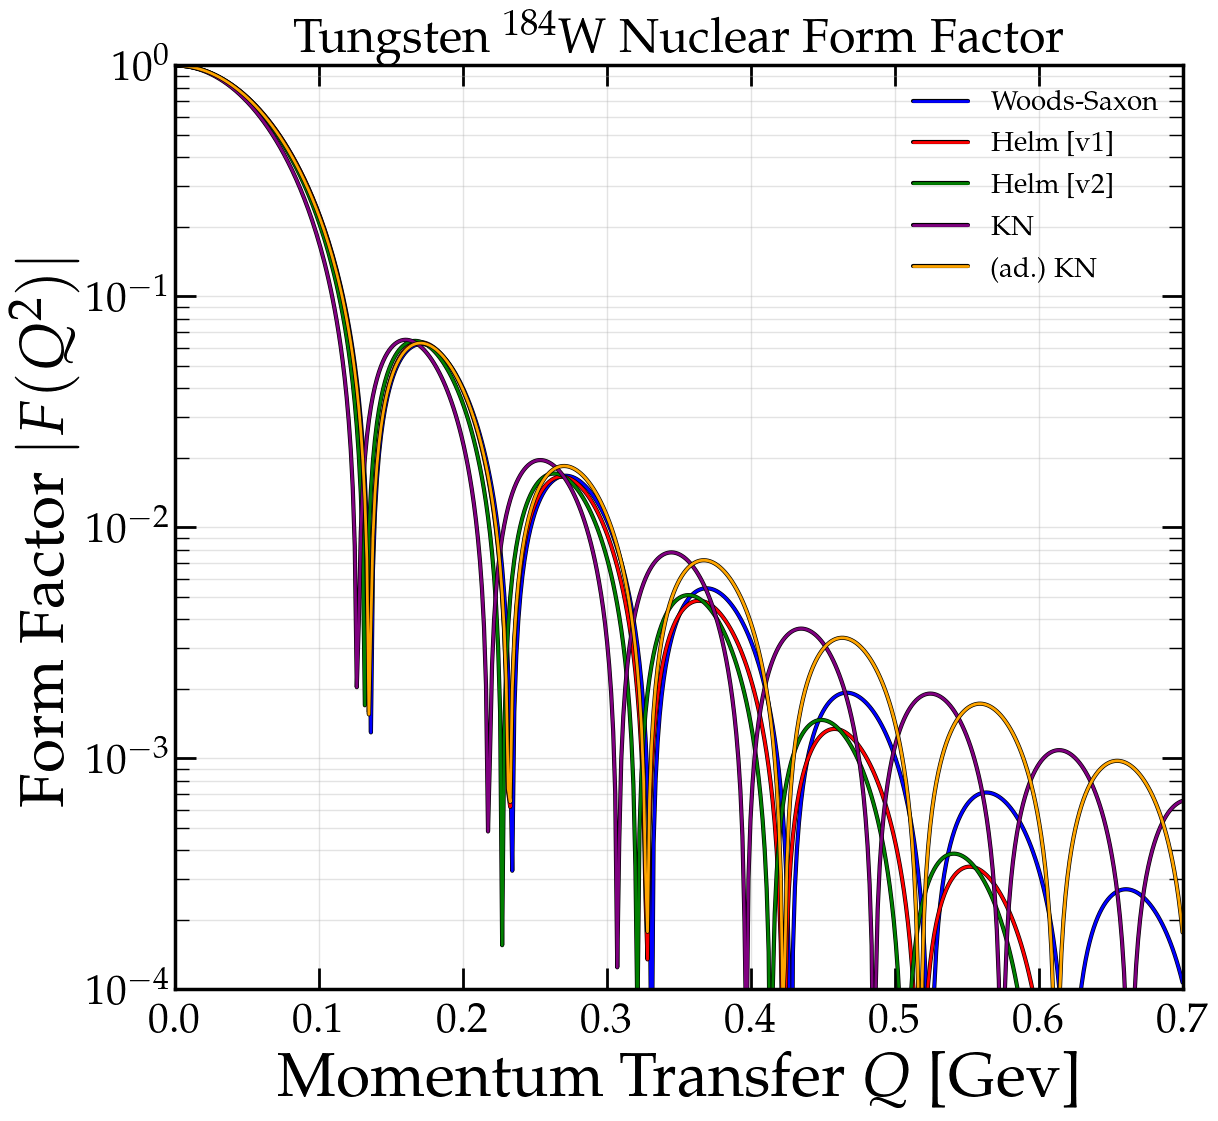

In [7]:
fig = plt.figure()
ax = fig.add_subplot()

ax.plot(Qvals, abs_WS_FF, color='blue', label='Woods-Saxon', lw=2, path_effects=[pe.Stroke(linewidth=3, foreground='k'), pe.Normal()])
ax.plot(Qvals, abs_Helmv1_FF, color='red', label='Helm [v1]', lw=2, path_effects=[pe.Stroke(linewidth=3, foreground='k'), pe.Normal()])
ax.plot(Qvals, abs_Helmv2_FF, color='green', label='Helm [v2]', lw=2, path_effects=[pe.Stroke(linewidth=3, foreground='k'), pe.Normal()])
ax.plot(Qvals, abs_KN_FF, color='purple', label='KN', lw=2, path_effects=[pe.Stroke(linewidth=3, foreground='k'), pe.Normal()])
ax.plot(Qvals, abs_adKN_FF, color='orange', label='(ad.) KN', lw=2, path_effects=[pe.Stroke(linewidth=3, foreground='k'), pe.Normal()])



ax.set_yscale('log')
ax.set_ylim([1e-4, 1])
ax.set_xlim([0, Qmax])

locmaj = matplotlib.ticker.LogLocator(base=10.0, subs=(1.0,), numticks=50)
locmin = matplotlib.ticker.LogLocator(base=10.0, subs=np.arange(2,10)*0.1, numticks=100)
ax.yaxis.set_major_locator(locmaj)
ax.yaxis.set_minor_locator(locmin)
ax.xaxis.grid(True, which='major', ls='-', alpha=0.35)
ax.yaxis.grid(True, which='both', ls='-', alpha=0.35)
ax.legend(fontsize=20, frameon=False, framealpha=1, edgecolor='k', fancybox=True)
ax.set_xlabel(r'Momentum Transfer $Q$ [Gev]')
ax.set_ylabel(r'Form Factor $|F(Q^2)|$')
ax.set_title(r'Tungsten $^{184}$W Nuclear Form Factor')

plt.savefig('../Plots/Figures_PDF/184TungstenFormFactor.pdf', transparent=False, bbox_inches='tight')
plt.savefig('../Plots/Figures_PNG/184TungstenFormFactor.png', transparent=False, bbox_inches='tight')